# Performance Analysis Report
Comparison of RDF Synthetic Data Generators

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Load the dataset
df = pd.read_csv('metrics_comparison.csv')
print(f"Loaded {len(df)} runs from {df['Generator'].nunique()} generators")
df.head()

Loaded 37 runs from 10 generators


,Generator,Run_ID,Perf_Throughput,Perf_Total_Triples,Perf_Execution_Time,RDF_Triples,RDF_Subjects,RDF_Predicates,RDF_Objects,RDF_Classes,RDF_Mean_Outdegree,RDF_Mean_Indegree,RDF_Coherence,RDF_Type_Coverage_Avg
0,BSBM,run_1,390985.958090,1809874,4.629000,1809874,168555,40,376738,337,10.737587,4.804065,0.949263,0.828470
1,BSBM,run_2,376351.424413,1809874,4.809000,1809874,168555,40,376738,337,10.737587,4.804065,0.949263,0.828470
2,BSBM,run_3,363136.837881,1809874,4.984000,1809874,168555,40,376738,337,10.737587,4.804065,0.949263,0.828470
3,BSBM,run_4,369739.325843,1809874,4.895000,1809874,168555,40,376738,337,10.737587,4.804065,0.949263,0.828470
4,GAIA,run_1,13039.422489,2580,0.260134,3392,955,32,434,50,3.551832,7.815668,0.429904,0.662587


/tmp/ipykernel_7252/1661828134.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Generator', y='Perf_Throughput', palette='viridis', order=generator_order, ax=ax_top)
/tmp/ipykernel_7252/1661828134.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Generator', y='Perf_Throughput', palette='viridis', order=generator_order, ax=ax_bottom)
/tmp/ipykernel_7252/1661828134.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


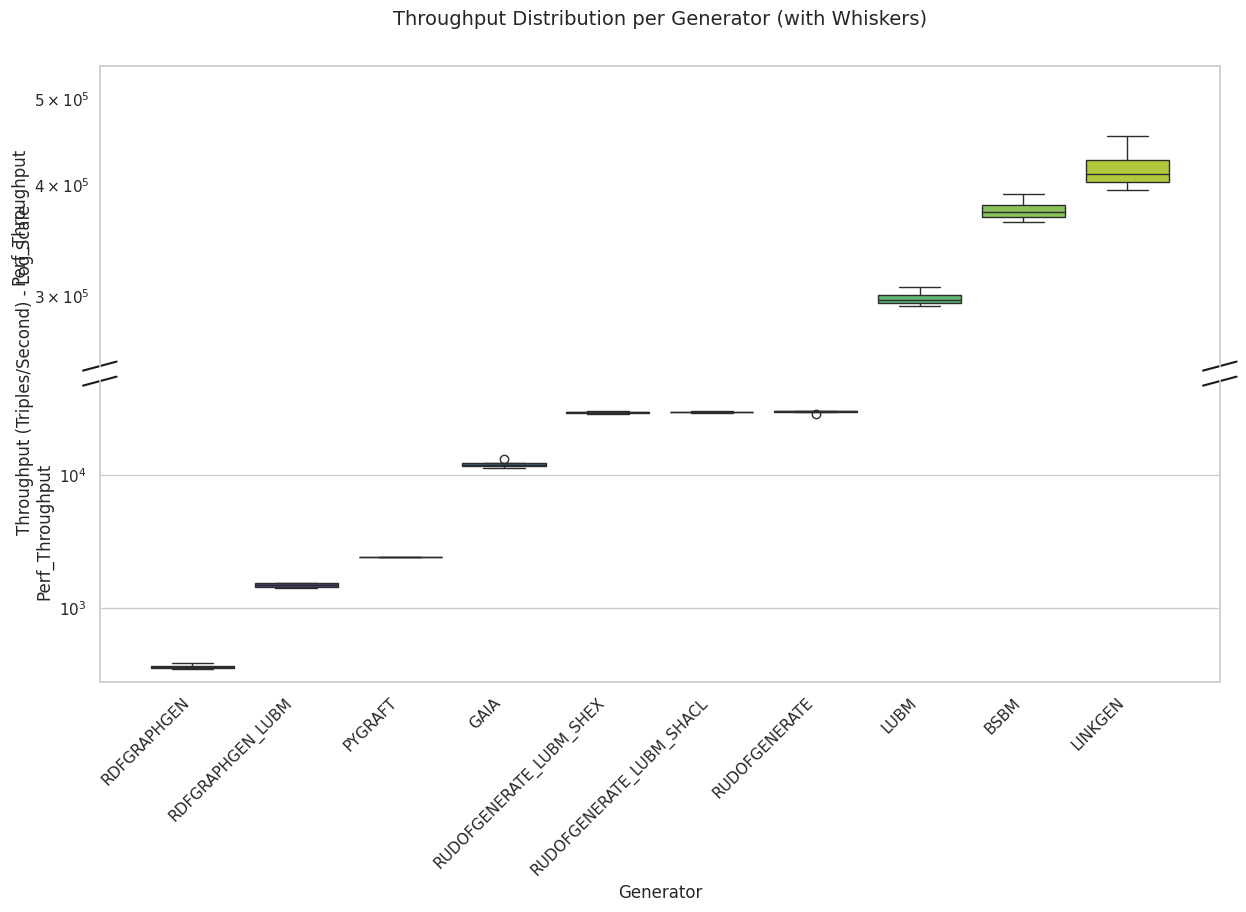

In [14]:
# Histogram 1: Throughput per Generator with Whiskers (Boxplot)
# Ordered from smallest to largest median throughput
# Using broken axis to handle large gap between low and high performers

from matplotlib.patches import ConnectionPatch

# Calculate median throughput per generator and sort
generator_order = df.groupby('Generator')['Perf_Throughput'].median().sort_values().index.tolist()

# Create figure with two subplots (broken axis)
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(14, 8), 
                                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})

# Plot the same data on both axes
sns.boxplot(data=df, x='Generator', y='Perf_Throughput', palette='viridis', order=generator_order, ax=ax_top)
sns.boxplot(data=df, x='Generator', y='Perf_Throughput', palette='viridis', order=generator_order, ax=ax_bottom)

# Set logarithmic scale for both axes
ax_top.set_yscale('log')
ax_bottom.set_yscale('log')

# Set the y-axis limits for each section (in log scale)
# Bottom section: low performers
# Top section: high performers
threshold_low = 50000
threshold_high = 250000

ax_bottom.set_ylim(df['Perf_Throughput'].min() * 0.8, threshold_low)
ax_top.set_ylim(threshold_high, df['Perf_Throughput'].max() * 1.2)

# Hide the spines between the two plots
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False)
ax_top.set_xlabel('')

# Add diagonal break marks
d = 0.015  # size of diagonal lines
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels
fig.suptitle('Throughput Distribution per Generator (with Whiskers)', fontsize=14, y=0.95)
ax_bottom.set_xlabel('Generator')
fig.text(0.04, 0.5, 'Throughput (Triples/Second) - Log Scale', va='center', rotation='vertical', fontsize=12)

ax_bottom.tick_params(axis='x', rotation=45)
for label in ax_bottom.get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

/tmp/ipykernel_7252/150680137.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Generator', y='RDF_Triples', palette='magma',
/tmp/ipykernel_7252/150680137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Generator', y='RDF_Triples', palette='magma',
/tmp/ipykernel_7252/150680137.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


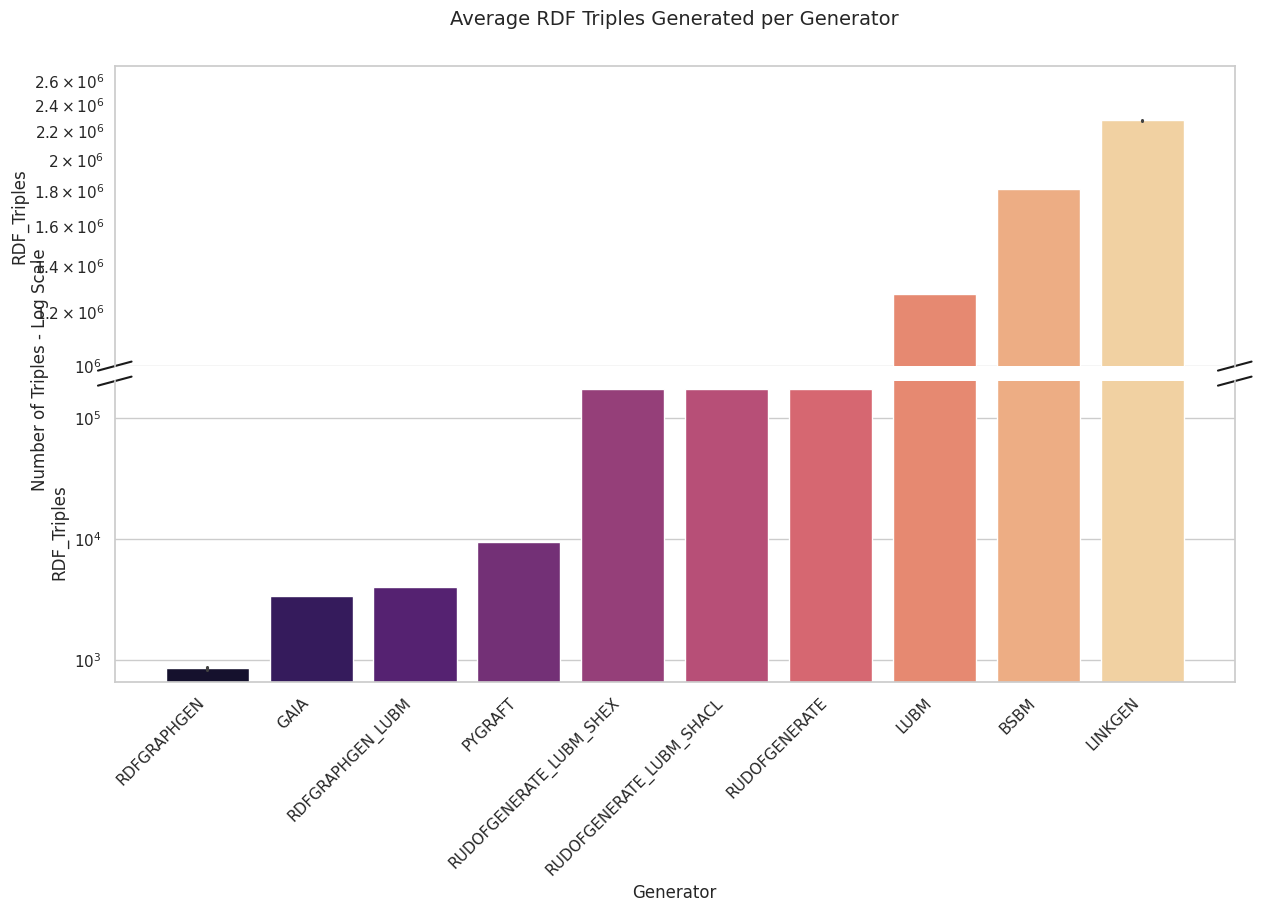

In [15]:
# Histogram 2: Triples Generated per Benchmark (Bar Chart)
# Ordered from smallest to largest
# Using broken axis to handle large gap between low and high performers

# Calculate mean triples per generator and sort
generator_order_triples = df.groupby('Generator')['RDF_Triples'].mean().sort_values().index.tolist()

# Create figure with two subplots (broken axis)
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(14, 8), 
                                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})

# Plot the same data on both axes
sns.barplot(data=df, x='Generator', y='RDF_Triples', palette='magma', 
            estimator=np.mean, errorbar='sd', order=generator_order_triples, ax=ax_top)
sns.barplot(data=df, x='Generator', y='RDF_Triples', palette='magma', 
            estimator=np.mean, errorbar='sd', order=generator_order_triples, ax=ax_bottom)

# Set logarithmic scale for both axes
ax_top.set_yscale('log')
ax_bottom.set_yscale('log')

# Set the y-axis limits for each section (in log scale)
# Based on the data: small generators vs large generators
threshold_low = 200000
threshold_high = 1000000

ax_bottom.set_ylim(df['RDF_Triples'].min() * 0.8, threshold_low)
ax_top.set_ylim(threshold_high, df['RDF_Triples'].max() * 1.2)

# Hide the spines between the two plots
ax_top.spines['bottom'].set_visible(False)
ax_bottom.spines['top'].set_visible(False)
ax_top.tick_params(bottom=False)
ax_top.set_xlabel('')

# Add diagonal break marks
d = 0.015
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Labels
fig.suptitle('Average RDF Triples Generated per Generator', fontsize=14, y=0.95)
ax_bottom.set_xlabel('Generator')
fig.text(0.04, 0.5, 'Number of Triples - Log Scale', va='center', rotation='vertical', fontsize=12)

ax_bottom.tick_params(axis='x', rotation=45)
for label in ax_bottom.get_xticklabels():
    label.set_ha('right')

plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

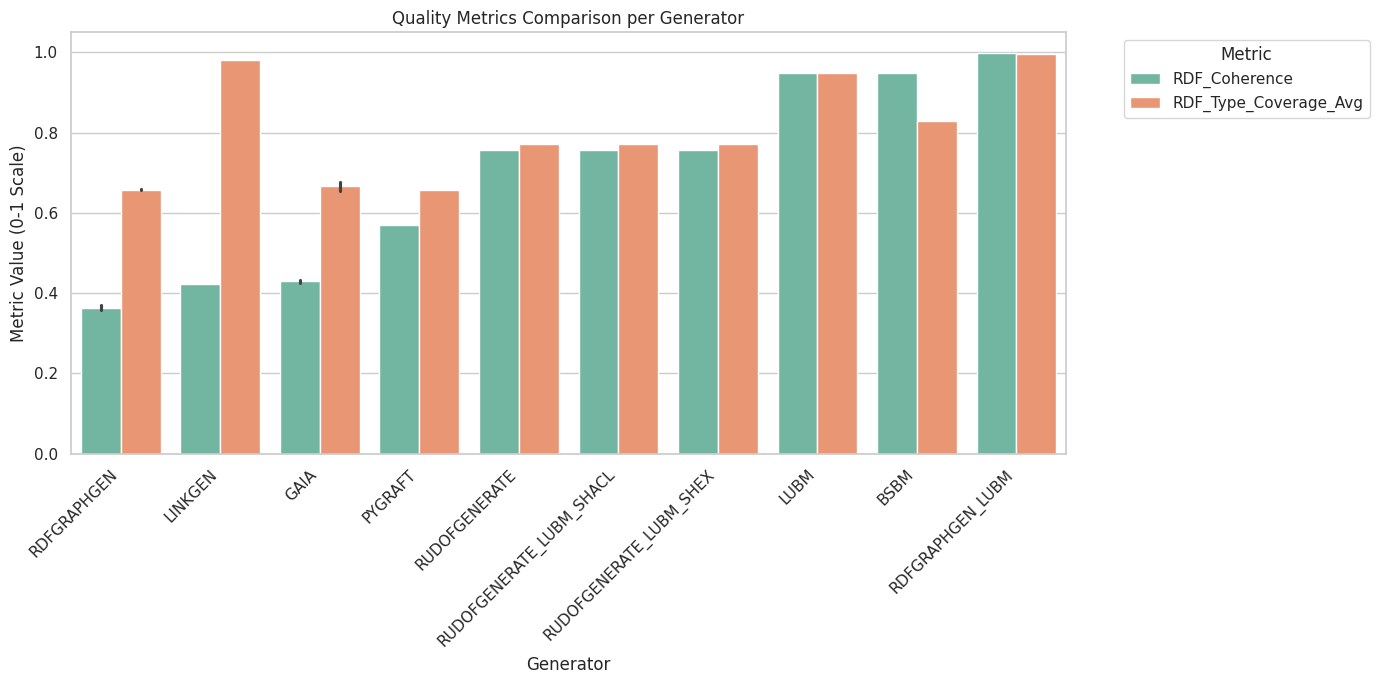

In [16]:
# Histogram 3: Other Metrics Grouped Together (Normalized for comparison)
# Metrics to compare: RDF_Coherence, RDF_Type_Coverage_Avg

# Calculate mean coherence per generator and sort
generator_order_quality = df.groupby('Generator')['RDF_Coherence'].mean().sort_values().index.tolist()

# Prepare data: Melt to long format for grouped bar chart
metrics_to_plot = ['RDF_Coherence', 'RDF_Type_Coverage_Avg']
df_melted = df.melt(id_vars=['Generator'], value_vars=metrics_to_plot, 
                    var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_melted, x='Generator', y='Value', hue='Metric', 
                 palette='Set2', order=generator_order_quality)

plt.title('Quality Metrics Comparison per Generator')
plt.xlabel('Generator')
plt.ylabel('Metric Value (0-1 Scale)')
plt.xticks(rotation=45, ha='right')

# Set y-axis limits from 0 to 1 (normalized metrics)
plt.ylim(0, 1.05)

plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()